# Stage 1 — FHIR Dataset Audit: Establishing the Reference Representation R0

**Purpose.** This notebook establishes `R0`, the reference representation used throughout the
information-preservation study: the **original, unmodified FHIR R4 resources** as produced by
Synthea, loaded read-only and inspected empirically.

**Scope constraints for this stage:**

- No transformation, flattening, feature engineering, or cleaning of the FHIR data.
- No imputation, normalization, or repair of detected issues — problems are only *reported*.
- No construction of R1/R2, no information-preservation scoring, no analytical workloads,
  no performance benchmarking.
- No assumptions about dataset paths, field names, or clinical importance — everything below is
  discovered from the data itself.
- The source dataset directory on disk is never written to.

**Outputs.** Machine-readable audit artifacts are written to `results/stage1/`.


## 0. Imports and repository root

In [1]:
import json
import os
import re
import sys
import platform
import random
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

def find_repo_root(start: Path) -> Path:
    # Walk upward from `start` until a `.git` directory is found.
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / "stage1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Results directory:", RESULTS_DIR)


Repository root: C:\Users\hmeln\sources\repos\FHIR-Transform
Results directory: C:\Users\hmeln\sources\repos\FHIR-Transform\results\stage1


## 1. Dataset discovery

We do not hard-code a dataset path. Instead we walk the repository, collect every directory that
contains a sizeable batch of `*.json` files (candidate FHIR export directories), and pick the
candidate whose file count is closest to the target of **~100 patients**. Directories that are
clearly not data (`.git`, the notebook's own venv, `notebooks/`, `results/`, etc.) are excluded
from the walk.


In [2]:
EXCLUDE_DIRS = {".git", ".venv", "venv", "node_modules", "notebooks", "results", ".ipynb_checkpoints", "__pycache__"}
MIN_JSON_FILES_FOR_CANDIDATE = 10
TARGET_PATIENT_COUNT = 100

candidates = []
for dirpath, dirnames, filenames in os.walk(REPO_ROOT):
    dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIRS]
    json_files_here = [f for f in filenames if f.lower().endswith(".json")]
    if len(json_files_here) >= MIN_JSON_FILES_FOR_CANDIDATE:
        total_size = sum((Path(dirpath) / f).stat().st_size for f in json_files_here)
        candidates.append({
            "path": Path(dirpath),
            "n_json_files": len(json_files_here),
            "total_size_bytes": total_size,
        })

candidates_df = pd.DataFrame([
    {
        "path": str(c["path"].relative_to(REPO_ROOT)),
        "n_json_files": c["n_json_files"],
        "total_size_mb": round(c["total_size_bytes"] / 1_000_000, 2),
        "abs_diff_from_target": abs(c["n_json_files"] - TARGET_PATIENT_COUNT),
    }
    for c in candidates
]).sort_values("abs_diff_from_target").reset_index(drop=True)

candidates_df


,path,n_json_files,total_size_mb,abs_diff_from_target
0,synthea_sample_data_fhir_latest,111,386.15,11
1,synthea_sample_data_fhir_r4_1K\fhir,557,1138.77,457


In [3]:
best = min(candidates, key=lambda c: abs(c["n_json_files"] - TARGET_PATIENT_COUNT))
DATASET_DIR = best["path"]

json_files = sorted(DATASET_DIR.glob("*.json"))
n_json_files = len(json_files)
total_size_bytes = sum(f.stat().st_size for f in json_files)

print("Selected dataset directory :", DATASET_DIR.relative_to(REPO_ROOT))
print("Number of JSON files       :", n_json_files)
print(f"Total disk size            : {total_size_bytes:,} bytes ({total_size_bytes / 1_000_000:.2f} MB)")


Selected dataset directory : synthea_sample_data_fhir_latest
Number of JSON files       : 111
Total disk size            : 386,150,705 bytes (386.15 MB)


## 2. Environment and reproducibility

In [4]:
env_info = {
    "python_version_full": sys.version,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "system": platform.system(),
    "machine": platform.machine(),
    "pandas_version": pd.__version__,
    "matplotlib_version": matplotlib.__version__,
    "random_seed": RANDOM_SEED,
    "audit_run_timestamp": datetime.now().isoformat(timespec="seconds"),
}
for k, v in env_info.items():
    print(f"{k:22s}: {v}")


python_version_full   : 3.14.6 (main, Jun 23 2026, 15:20:04) [MSC v.1944 64 bit (AMD64)]
python_version        : 3.14.6
platform              : Windows-11-10.0.26200-SP0
system                : Windows
machine               : AMD64
pandas_version        : 3.0.6
matplotlib_version    : 3.11.2
random_seed           : 42
audit_run_timestamp   : 2026-09-26T18:49:27


## 3. FHIR structure inspection

Every JSON file in the dataset directory is parsed **read-only** (no field is modified). For each
file we record the top-level `resourceType`, the Bundle `type`, the number of `entry` elements,
the `resourceType` of the first entry, and the distribution of `resourceType` values inside the
bundle. This tells us empirically whether the files are FHIR Bundles, what Bundle type they use,
and whether one Bundle corresponds to one patient — without assuming any of this in advance.


In [5]:
raw_data = {}
parse_errors = []
for fp in json_files:
    try:
        with open(fp, encoding="utf-8") as f:
            raw_data[fp.name] = json.load(f)
    except Exception as e:
        parse_errors.append({"file": fp.name, "error": str(e)})

print(f"Successfully parsed : {len(raw_data)} / {len(json_files)}")
print(f"Parse errors        : {len(parse_errors)}")
if parse_errors:
    display(pd.DataFrame(parse_errors))


Successfully parsed : 111 / 111
Parse errors        : 0


In [6]:
bundle_rows = []
for fname, data in raw_data.items():
    top_resource_type = data.get("resourceType")
    bundle_type = data.get("type")
    entries = data.get("entry", [])
    n_entries = len(entries)
    first_rt = None
    if entries and "resource" in entries[0]:
        first_rt = entries[0]["resource"].get("resourceType")
    rt_counts = Counter(
        e["resource"].get("resourceType") for e in entries if "resource" in e
    )
    bundle_rows.append({
        "file": fname,
        "resourceType": top_resource_type,
        "bundle_type": bundle_type,
        "n_entries": n_entries,
        "first_entry_resourceType": first_rt,
        "n_distinct_resource_types": len(rt_counts),
        "n_patient_resources_in_bundle": rt_counts.get("Patient", 0),
    })

bundle_structure_df = pd.DataFrame(bundle_rows)
bundle_structure_df["is_patient_bundle"] = (
    (bundle_structure_df["first_entry_resourceType"] == "Patient")
    & (bundle_structure_df["n_patient_resources_in_bundle"] == 1)
)

print("Top-level resourceType values found:", bundle_structure_df["resourceType"].unique().tolist())
print()
print("Bundle `type` distribution:")
print(bundle_structure_df["bundle_type"].value_counts())
print()
n_patient_bundles = int(bundle_structure_df["is_patient_bundle"].sum())
print(f"Bundles that correspond to exactly one Patient: {n_patient_bundles} / {len(bundle_structure_df)}")


Top-level resourceType values found: ['Bundle']

Bundle `type` distribution:
bundle_type
transaction    109
batch            2
Name: count, dtype: int64

Bundles that correspond to exactly one Patient: 109 / 111


In [7]:
print("Entries per Bundle — summary statistics:")
bundle_structure_df["n_entries"].describe()


Entries per Bundle — summary statistics:


count      111.00000
mean      1080.90991
std       2226.06784
min         47.00000
25%        437.00000
50%        623.00000
75%        895.00000
max      18551.00000
Name: n_entries, dtype: float64

In [8]:
support_files_df = bundle_structure_df[~bundle_structure_df["is_patient_bundle"]]
print(f"Non-patient support files/bundles: {len(support_files_df)}")
support_files_df


Non-patient support files/bundles: 2


,file,resourceType,bundle_type,n_entries,first_entry_resourceType,n_distinct_resource_types,n_patient_resources_in_bundle,is_patient_bundle
53,hospitalInformation1787069559744.json,Bundle,batch,557,Organization,2,0,False
90,practitionerInformation1787069559744.json,Bundle,batch,556,Practitioner,2,0,False


## 4. Resource inventory

We index every FHIR resource found inside every `entry` of every file (patient bundles *and*
support files, e.g. `hospitalInformation*.json` / `practitionerInformation*.json`, since they are
also part of the R0 corpus) — without altering the underlying resource dictionaries.


In [9]:
all_resources = []  # each item: {"file": <filename>, "resource": <raw resource dict, untouched>}
resources_without_resourcetype = []

for fname, data in raw_data.items():
    for e in data.get("entry", []):
        res = e.get("resource")
        if res is None:
            continue
        if "resourceType" not in res:
            resources_without_resourcetype.append({"file": fname, "entry_fullUrl": e.get("fullUrl")})
        all_resources.append({"file": fname, "resource": res})

total_resources = len(all_resources)
print("Total FHIR resources across dataset:", total_resources)
print("Resources missing 'resourceType'   :", len(resources_without_resourcetype))


Total FHIR resources across dataset: 119981
Resources missing 'resourceType'   : 0


In [10]:
resource_type_counts = Counter(r["resource"].get("resourceType") for r in all_resources)

resource_counts_df = (
    pd.DataFrame([{"resourceType": rt, "count": c} for rt, c in resource_type_counts.items()])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
resource_counts_df["percentage"] = (resource_counts_df["count"] / total_resources * 100).round(3)
resource_counts_df


,resourceType,count,percentage
0,Observation,46305,38.594
1,Procedure,16063,13.388
2,DiagnosticReport,11013,9.179
3,Claim,9493,7.912
4,ExplanationOfBenefit,9493,7.912
5,Encounter,5635,4.697
6,DocumentReference,5635,4.697
7,MedicationRequest,3858,3.216
8,Condition,3540,2.950
9,SupplyDelivery,2242,1.869


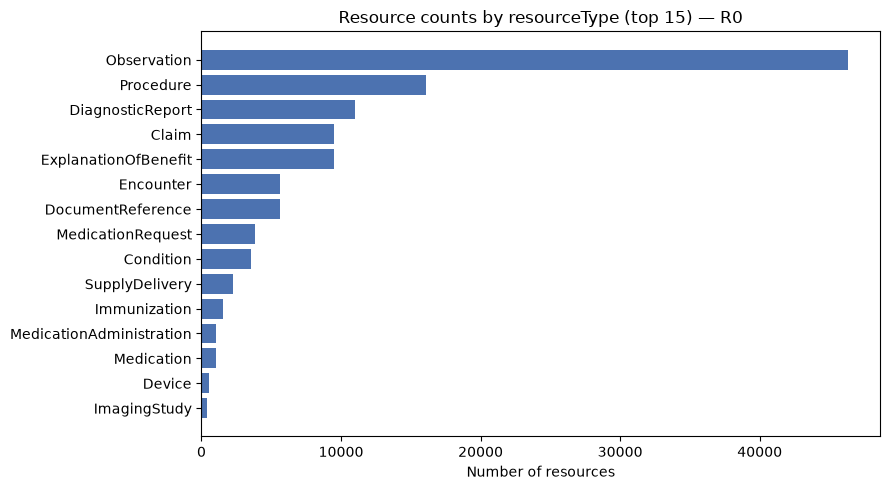

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
top_n = resource_counts_df.head(15)
ax.barh(top_n["resourceType"][::-1], top_n["count"][::-1], color="#4C72B0")
ax.set_xlabel("Number of resources")
ax.set_title("Resource counts by resourceType (top 15) — R0")
plt.tight_layout()
plt.show()


## 5. Target resource inspection

Focused detail on the five resource types of primary interest for the downstream
information-preservation study: `Patient`, `Encounter`, `Condition`, `Observation`,
`MedicationRequest`. All other resource types remain in `resource_counts_df` above and are not
discarded.


In [12]:
TARGET_RESOURCE_TYPES = ["Patient", "Encounter", "Condition", "Observation", "MedicationRequest"]

n_patients = n_patient_bundles  # denominator for "per patient" averages, derived in Section 3

target_summary_rows = []
resources_by_target_type = {}
for rt in TARGET_RESOURCE_TYPES:
    resources = [r["resource"] for r in all_resources if r["resource"].get("resourceType") == rt]
    resources_by_target_type[rt] = resources
    ids = [res.get("id") for res in resources]
    n_total = len(resources)
    n_missing_ids = sum(1 for i in ids if i is None)
    n_unique_ids = len({i for i in ids if i is not None})
    avg_per_patient = round(n_total / n_patients, 3) if n_patients else None
    target_summary_rows.append({
        "resourceType": rt,
        "n_resources": n_total,
        "n_unique_ids": n_unique_ids,
        "n_missing_ids": n_missing_ids,
        "avg_per_patient": avg_per_patient,
    })

target_summary_df = pd.DataFrame(target_summary_rows)
target_summary_df


,resourceType,n_resources,n_unique_ids,n_missing_ids,avg_per_patient
0,Patient,109,109,0,1.000
1,Encounter,5635,5635,0,51.697
2,Condition,3540,3540,0,32.477
3,Observation,46305,46305,0,424.817
4,MedicationRequest,3858,3858,0,35.394


## 6. Relationship audit

We do not assume which reference fields exist. For every resource of the five target types we
scan its top-level fields for FHIR `Reference` objects (`{"reference": "..."}`, optionally with a
`display`), and record every distinct `(source resourceType, field name)` pair actually observed.

An identifier index (`system|value` -> resource) is built from every resource's `identifier` array
so that conditional references (e.g. `Practitioner?identifier=...`) can also be checked for
resolvability, in addition to direct `urn:uuid:...` references.


In [13]:
# Index 1: resource id -> resourceType, for direct urn:uuid:<id> resolution
id_to_type = {}
for r in all_resources:
    rid = r["resource"].get("id")
    rt = r["resource"].get("resourceType")
    if rid is not None:
        id_to_type[rid] = rt

# Index 2: (system, value) -> resourceType, for conditional identifier-based references
identifier_index = {}
for r in all_resources:
    res = r["resource"]
    rt = res.get("resourceType")
    for ident in res.get("identifier", []) or []:
        system = ident.get("system")
        value = ident.get("value")
        if system is not None and value is not None:
            identifier_index[(system, value)] = rt

print("Resources indexed by id        :", len(id_to_type))
print("Distinct (system,value) identifiers indexed:", len(identifier_index))


Resources indexed by id        : 119981
Distinct (system,value) identifiers indexed: 22515


In [14]:
def parse_reference(ref: str):
    # Classify a FHIR reference string and extract what is needed to resolve it.
    if ref.startswith("urn:uuid:"):
        return "urn:uuid", ref[len("urn:uuid:"):]
    m = re.match(r"^([A-Za-z]+)\?identifier=([^|]+)\|(.+)$", ref)
    if m:
        target_type_hint, system, value = m.groups()
        return "conditional-identifier", (target_type_hint, system, value)
    m = re.match(r"^([A-Za-z]+)/(.+)$", ref)
    if m:
        return "relative", m.groups()
    return "other", ref


relationship_records = []  # one row per observed reference instance
for rt in TARGET_RESOURCE_TYPES:
    for res in resources_by_target_type[rt]:
        for field, value in res.items():
            candidates_ = []
            if isinstance(value, dict) and "reference" in value:
                candidates_.append(value)
            elif isinstance(value, list):
                candidates_.extend(v for v in value if isinstance(v, dict) and "reference" in v)
            for cand in candidates_:
                ref = cand.get("reference")
                if not isinstance(ref, str):
                    continue
                kind, parsed = parse_reference(ref)
                if kind == "urn:uuid":
                    target_id = parsed
                    resolved_type = id_to_type.get(target_id)
                    resolvable = resolved_type is not None
                elif kind == "conditional-identifier":
                    target_type_hint, system, value_ = parsed
                    resolved_type = identifier_index.get((system, value_))
                    resolvable = resolved_type is not None
                elif kind == "relative":
                    target_type_hint, target_id = parsed
                    resolved_type = id_to_type.get(target_id)
                    resolvable = resolved_type is not None
                else:
                    resolved_type = None
                    resolvable = False
                relationship_records.append({
                    "source_resourceType": rt,
                    "reference_field": field,
                    "reference_kind": kind,
                    "resolved_target_resourceType": resolved_type,
                    "resolvable": resolvable,
                })

relationship_raw_df = pd.DataFrame(relationship_records)
print("Total individual references inspected:", len(relationship_raw_df))
relationship_raw_df.groupby(["source_resourceType", "reference_field"]).size().sort_values(ascending=False)


Total individual references inspected: 126293


source_resourceType  reference_field    
Observation          encounter              46305
                     subject                46305
Encounter            serviceProvider         5635
                     subject                 5635
MedicationRequest    requester               3858
                     subject                 3858
                     encounter               3858
Condition            subject                 3540
                     encounter               3540
MedicationRequest    reasonReference         2733
                     medicationReference     1026
dtype: int64

In [15]:
relationship_audit_df = (
    relationship_raw_df
    .groupby(["source_resourceType", "reference_field", "resolved_target_resourceType"], dropna=False)
    .agg(n_references=("resolvable", "size"), n_resolvable=("resolvable", "sum"))
    .reset_index()
)
relationship_audit_df["pct_resolvable"] = (
    relationship_audit_df["n_resolvable"] / relationship_audit_df["n_references"] * 100
).round(2)
relationship_audit_df = relationship_audit_df.sort_values(
    ["source_resourceType", "reference_field"]
).reset_index(drop=True)
relationship_audit_df.rename(columns={"resolved_target_resourceType": "target_resourceType"}, inplace=True)
relationship_audit_df


,source_resourceType,reference_field,target_resourceType,n_references,n_resolvable,pct_resolvable
0,Condition,encounter,Encounter,3540,3540,100.0
1,Condition,subject,Patient,3540,3540,100.0
2,Encounter,serviceProvider,Organization,5635,5635,100.0
3,Encounter,subject,Patient,5635,5635,100.0
4,MedicationRequest,encounter,Encounter,3858,3858,100.0
5,MedicationRequest,medicationReference,Medication,1026,1026,100.0
6,MedicationRequest,reasonReference,Condition,2733,2733,100.0
7,MedicationRequest,requester,Practitioner,3858,3858,100.0
8,MedicationRequest,subject,Patient,3858,3858,100.0
9,Observation,encounter,Encounter,46305,46305,100.0


In [16]:
n_relationships_inspected = int(relationship_audit_df["n_references"].sum())
n_relationships_resolvable = int(relationship_audit_df["n_resolvable"].sum())
pct_relationships_resolvable = round(n_relationships_resolvable / n_relationships_inspected * 100, 2) if n_relationships_inspected else None

print(f"References inspected total : {n_relationships_inspected}")
print(f"References resolvable      : {n_relationships_resolvable} ({pct_relationships_resolvable}%)")


References inspected total : 126293
References resolvable      : 126293 (100.0%)


## 7. Temporal information audit

Temporal fields are *discovered*, not assumed: for every top-level field of every target-type
resource we test whether its value (a string, or the `start`/`end` of a nested Period-like dict)
matches an ISO-8601 date or date-time pattern. Whichever field names actually pass this test on
real data are reported.


In [17]:
DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
DATETIME_RE = re.compile(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}")

def looks_temporal(value: str) -> bool:
    return bool(DATE_RE.match(value) or DATETIME_RE.match(value))

def has_timezone(value: str) -> bool:
    return value.endswith("Z") or bool(re.search(r"[+-]\d{2}:\d{2}$", value))

temporal_records = []  # per-occurrence records, later aggregated
for rt in TARGET_RESOURCE_TYPES:
    for res in resources_by_target_type[rt]:
        for field, value in res.items():
            if isinstance(value, str) and looks_temporal(value):
                temporal_records.append({
                    "resourceType": rt, "field": field, "value": value,
                    "has_tz": has_timezone(value) if DATETIME_RE.match(value) else None,
                })
            elif isinstance(value, dict) and ("start" in value or "end" in value):
                sub = value.get("start") or value.get("end")
                if isinstance(sub, str) and looks_temporal(sub):
                    for sub_field in ("start", "end"):
                        sub_val = value.get(sub_field)
                        if isinstance(sub_val, str) and looks_temporal(sub_val):
                            temporal_records.append({
                                "resourceType": rt, "field": f"{field}.{sub_field}", "value": sub_val,
                                "has_tz": has_timezone(sub_val) if DATETIME_RE.match(sub_val) else None,
                            })

temporal_raw_df = pd.DataFrame(temporal_records)
print("Temporal value occurrences found:", len(temporal_raw_df))


Temporal value occurrences found: 117582


In [18]:
def summarize_temporal(group):
    non_null = group["value"].dropna()
    tz_values = group["has_tz"].dropna()
    return pd.Series({
        "n_occurrences": len(non_null),
        "example_value": non_null.iloc[0] if len(non_null) else None,
        "has_timezone_info": bool(tz_values.any()) if len(tz_values) else None,
    })

temporal_fields_df = (
    temporal_raw_df.groupby(["resourceType", "field"])
    .apply(summarize_temporal, include_groups=False)
    .reset_index()
    .sort_values(["resourceType", "n_occurrences"], ascending=[True, False])
    .reset_index(drop=True)
)
temporal_fields_df


,resourceType,field,n_occurrences,example_value,has_timezone_info
0,Condition,onsetDateTime,3540,1999-07-19T23:00:52+00:00,True
1,Condition,recordedDate,3540,1999-07-19T23:00:52+00:00,True
2,Condition,abatementDateTime,2646,2023-06-05T23:12:14+00:00,True
3,Encounter,period.end,5635,1999-07-19T23:00:52+00:00,True
4,Encounter,period.start,5635,1999-07-19T22:20:00+00:00,True
5,MedicationRequest,authoredOn,3858,2005-06-05T22:20:00+00:00,True
6,Observation,effectiveDateTime,46305,2016-12-05T22:20:00+00:00,True
7,Observation,issued,46305,2016-12-05T22:20:00.256+00:00,True
8,Patient,birthDate,109,1981-05-25,None
9,Patient,deceasedDateTime,9,2023-08-22T15:37:22+00:00,True


## 8. Attribute / structure audit

For each target resource type we report, without flattening anything:

- every top-level field name and how often it occurs (count and percentage of resources of that
  type),
- whether the field's value is a *nested structure* (object or array of objects) versus a
  scalar/reference/temporal value already covered above.


In [19]:
REFERENCE_FIELD_NAMES = set(relationship_raw_df["reference_field"].unique()) if len(relationship_raw_df) else set()
TEMPORAL_FIELD_BASE_NAMES = {f.split(".")[0] for f in temporal_fields_df["field"].unique()} if len(temporal_fields_df) else set()

def classify_value(field, value):
    if field in REFERENCE_FIELD_NAMES and (
        (isinstance(value, dict) and "reference" in value)
        or (isinstance(value, list) and any(isinstance(v, dict) and "reference" in v for v in value))
    ):
        return "reference"
    if field in TEMPORAL_FIELD_BASE_NAMES and (
        isinstance(value, str) or (isinstance(value, dict) and ("start" in value or "end" in value))
    ):
        return "temporal"
    if isinstance(value, dict):
        return "nested_object"
    if isinstance(value, list) and value and isinstance(value[0], dict):
        return "nested_array_of_objects"
    if isinstance(value, list):
        return "array_of_scalars"
    return "scalar"

field_rows = []
for rt in TARGET_RESOURCE_TYPES:
    resources = resources_by_target_type[rt]
    n_rt = len(resources)
    field_counter = Counter()
    field_kind_examples = {}
    for res in resources:
        for field, value in res.items():
            field_counter[field] += 1
            field_kind_examples.setdefault(field, classify_value(field, value))
    for field, count in field_counter.items():
        field_rows.append({
            "resourceType": rt,
            "field": field,
            "n_occurrences": count,
            "pct_of_resources": round(count / n_rt * 100, 2) if n_rt else None,
            "value_kind": field_kind_examples[field],
        })

field_occurrence_df = pd.DataFrame(field_rows).sort_values(
    ["resourceType", "pct_of_resources"], ascending=[True, False]
).reset_index(drop=True)
field_occurrence_df


,resourceType,field,n_occurrences,pct_of_resources,value_kind
0,Condition,resourceType,3540,100.00,scalar
1,Condition,id,3540,100.00,scalar
2,Condition,meta,3540,100.00,nested_object
3,Condition,clinicalStatus,3540,100.00,nested_object
4,Condition,verificationStatus,3540,100.00,nested_object
...,...,...,...,...,...
66,Patient,maritalStatus,109,100.00,nested_object
67,Patient,communication,109,100.00,nested_array_of_objects
68,Patient,multipleBirthBoolean,105,96.33,scalar
69,Patient,deceasedDateTime,9,8.26,temporal


In [20]:
print("Nested structures (objects / arrays-of-objects) identified per target resourceType, by field:")
field_occurrence_df[field_occurrence_df["value_kind"].isin(["nested_object", "nested_array_of_objects"])]


Nested structures (objects / arrays-of-objects) identified per target resourceType, by field:


,resourceType,field,n_occurrences,pct_of_resources,value_kind
2,Condition,meta,3540,100.00,nested_object
3,Condition,clinicalStatus,3540,100.00,nested_object
4,Condition,verificationStatus,3540,100.00,nested_object
5,Condition,category,3540,100.00,nested_array_of_objects
6,Condition,code,3540,100.00,nested_object
14,Encounter,meta,5635,100.00,nested_object
15,Encounter,identifier,5635,100.00,nested_array_of_objects
17,Encounter,class,5635,100.00,nested_object
18,Encounter,type,5635,100.00,nested_array_of_objects
20,Encounter,participant,5635,100.00,nested_array_of_objects


## 9. Basic validation

Detected issues are only *reported* here — nothing is repaired.


In [21]:
duplicate_id_rows = []
missing_id_rows = []
for rt in resource_counts_df["resourceType"]:
    resources = [r["resource"] for r in all_resources if r["resource"].get("resourceType") == rt]
    ids = [res.get("id") for res in resources]
    id_counts = Counter(i for i in ids if i is not None)
    dupes = {i: c for i, c in id_counts.items() if c > 1}
    n_missing = sum(1 for i in ids if i is None)
    if dupes:
        duplicate_id_rows.append({"resourceType": rt, "n_duplicate_ids": len(dupes), "n_extra_occurrences": sum(dupes.values()) - len(dupes)})
    if n_missing:
        missing_id_rows.append({"resourceType": rt, "n_missing_ids": n_missing})

duplicate_ids_df = pd.DataFrame(duplicate_id_rows)
missing_ids_df = pd.DataFrame(missing_id_rows)

print("Resource types with duplicate IDs:")
display(duplicate_ids_df if len(duplicate_ids_df) else "None found")
print()
print("Resource types with missing IDs:")
display(missing_ids_df if len(missing_ids_df) else "None found")


Resource types with duplicate IDs:


'None found'


Resource types with missing IDs:


'None found'

In [22]:
broken_reference_rows = relationship_audit_df[relationship_audit_df["n_resolvable"] < relationship_audit_df["n_references"]].copy()
broken_reference_rows["n_broken"] = broken_reference_rows["n_references"] - broken_reference_rows["n_resolvable"]

print("Reference fields with at least one unresolvable reference:")
display(broken_reference_rows[["source_resourceType", "reference_field", "target_resourceType", "n_references", "n_broken"]]
        if len(broken_reference_rows) else "None found")
print()
print("Malformed JSON files:", len(parse_errors))
if parse_errors:
    display(pd.DataFrame(parse_errors))
print()
print("Resources without 'resourceType':", len(resources_without_resourcetype))
if resources_without_resourcetype:
    display(pd.DataFrame(resources_without_resourcetype))


Reference fields with at least one unresolvable reference:


'None found'


Malformed JSON files: 0

Resources without 'resourceType': 0


## 10. Summary and machine-readable outputs

In [23]:
dataset_summary = {
    "dataset_path": str(DATASET_DIR.relative_to(REPO_ROOT)),
    "n_json_files": n_json_files,
    "total_size_bytes": int(total_size_bytes),
    "environment": env_info,
    "n_patient_bundles": int(n_patient_bundles),
    "n_total_fhir_resources": int(total_resources),
    "target_resource_counts": {
        row["resourceType"]: int(row["n_resources"]) for row in target_summary_rows
    },
    "n_relationships_inspected": n_relationships_inspected,
    "n_relationships_resolvable": n_relationships_resolvable,
    "pct_relationships_resolvable": pct_relationships_resolvable,
    "n_temporal_fields_identified": int(temporal_fields_df.shape[0]),
    "data_quality_issues": {
        "n_resource_types_with_duplicate_ids": int(len(duplicate_ids_df)),
        "n_resource_types_with_missing_ids": int(len(missing_ids_df)),
        "n_reference_fields_with_broken_references": int(len(broken_reference_rows)),
        "n_malformed_json_files": len(parse_errors),
        "n_resources_without_resourcetype": len(resources_without_resourcetype),
    },
}

print("=" * 70)
print("STAGE 1 — R0 AUDIT SUMMARY")
print("=" * 70)
print(f"Patient Bundles                : {dataset_summary['n_patient_bundles']}")
print(f"Total FHIR resources           : {dataset_summary['n_total_fhir_resources']}")
for rt, c in dataset_summary["target_resource_counts"].items():
    print(f"  {rt:<18}: {c}")
print(f"Relationships inspected        : {dataset_summary['n_relationships_inspected']}")
print(f"Relationships resolvable       : {dataset_summary['pct_relationships_resolvable']}%")
print(f"Temporal fields identified     : {dataset_summary['n_temporal_fields_identified']}")
print("Data quality issues:")
for k, v in dataset_summary["data_quality_issues"].items():
    print(f"  {k:<45}: {v}")
print("=" * 70)


STAGE 1 — R0 AUDIT SUMMARY
Patient Bundles                : 109
Total FHIR resources           : 119981
  Patient           : 109
  Encounter         : 5635
  Condition         : 3540
  Observation       : 46305
  MedicationRequest : 3858
Relationships inspected        : 126293
Relationships resolvable       : 100.0%
Temporal fields identified     : 10
Data quality issues:
  n_resource_types_with_duplicate_ids          : 0
  n_resource_types_with_missing_ids            : 0
  n_reference_fields_with_broken_references    : 0
  n_malformed_json_files                       : 0
  n_resources_without_resourcetype             : 0


In [24]:
resource_counts_df.to_csv(RESULTS_DIR / "resource_counts.csv", index=False)
relationship_audit_df.to_csv(RESULTS_DIR / "relationship_audit.csv", index=False)
temporal_fields_df.to_csv(RESULTS_DIR / "temporal_fields.csv", index=False)
field_occurrence_df.to_csv(RESULTS_DIR / "field_occurrence.csv", index=False)

with open(RESULTS_DIR / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, indent=2)

# Supplementary artifacts (not required, but useful downstream and cheap to keep)
bundle_structure_df.to_csv(RESULTS_DIR / "bundle_structure.csv", index=False)
target_summary_df.to_csv(RESULTS_DIR / "target_resource_summary.csv", index=False)
candidates_df.to_csv(RESULTS_DIR / "dataset_candidates.csv", index=False)
if len(duplicate_ids_df):
    duplicate_ids_df.to_csv(RESULTS_DIR / "duplicate_ids.csv", index=False)
if len(missing_ids_df):
    missing_ids_df.to_csv(RESULTS_DIR / "missing_ids.csv", index=False)

print("Saved audit artifacts to:", RESULTS_DIR.relative_to(REPO_ROOT))
for p in sorted(RESULTS_DIR.iterdir()):
    print(" -", p.name)


Saved audit artifacts to: results\stage1
 - bundle_structure.csv
 - dataset_candidates.csv
 - dataset_summary.json
 - field_occurrence.csv
 - relationship_audit.csv
 - resource_counts.csv
 - target_resource_summary.csv
 - temporal_fields.csv
